# 📊 Universal CSV Analysis & ML Template
### Reusable Data Analysis + Machine Learning Notebook
---
**Instructions:** Edit **Cell 1 (Configuration)** only — set your CSV path, charts folder, and target column.
Everything else runs automatically.

**Sections:**
1. [Configuration](#1-config) ← Edit this cell only
2. [Setup & Imports](#2-setup)
3. [Load Data](#3-load)
4. [Data Quality Report](#4-quality)
5. [Data Cleaning](#5-cleaning)
6. [Exploratory Data Analysis (EDA)](#6-eda)
7. [Feature Engineering](#7-features)
8. [Model Training](#8-model)
9. [Evaluation & Metrics](#9-metrics)
10. [Residual Analysis](#10-residuals)
11. [Save Model & Summary](#11-save)


## 1. ⚙️ Configuration — Edit This Cell Only <a id="1-config"></a>

> **Fill in the three paths/settings below, then run all cells.**

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  PROJECT CONFIGURATION — EDIT THESE LINES BEFORE RUNNING
# ═════════════════════════════════════════════════════════════════════
columns_to_drop = []
# Path to your CSV file
# Example (Windows): r"C:\Users\amjad\Projects\Assignment_4\data\mydata.csv"
# Example (Mac/Linux): "/home/amjad/projects/data/mydata.csv"
csv_file_path = r"C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\data\insurance.csv"

# Folder where all charts will be saved as PNG files
# Example (Windows): r"C:\Users\amjad\Projects\Assignment_4\charts"
# Example (Mac/Linux): "/home/amjad/projects/charts"
charts_output_folder = r"C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts"

# Folder where the trained model (.pkl) will be saved
# Example (Windows): r"C:\Users\amjad\Projects\Assignment_4\models"
models_output_folder = r"C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\modelsLDER_PATH_HERE"

# Name of the column you want to PREDICT (the target/label column)
# Example: "charges", "price", "salary", "sales"
target_column = "charges"

# (Optional) Columns to DROP before analysis — e.g. ID columns, names, timestamps
# Set to an empty list [] if you don't want to drop anything
# Example: ["id", "name", "timestamp"]
columns_to_drop = []

# Test split ratio (0.2 = 80% train, 20% test)
test_size = 0.20

# Random seed for reproducibility
random_state = 42

# ══════════════════════════════════════════════════════════════════════
print("✓ Configuration loaded.")
print(f"  CSV path    : {csv_file_path}")
print(f"  Charts path : {charts_output_folder}")
print(f"  Models path : {models_output_folder}")
print(f"  Target col  : {target_column}")


✓ Configuration loaded.
  CSV path    : C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\data\medical_cost.csv
  Charts path : C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts
  Models path : C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\modelsLDER_PATH_HERE
  Target col  : charges


## 2. 📦 Setup & Imports <a id="2-setup"></a>

In [2]:
# ── Standard Library ────────────────────────────────────────────────
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Data & Numerics ─────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

# ── Plotting Defaults ───────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.family'   : 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# ── Auto-create output folders ──────────────────────────────────────
os.makedirs(charts_output_folder, exist_ok=True)
os.makedirs(models_output_folder, exist_ok=True)

print("✓ All libraries imported successfully")
print(f"✓ Charts folder ready  : {charts_output_folder}")
print(f"✓ Models folder ready  : {models_output_folder}")
print(f"  pandas  {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {matplotlib.__version__}")


✓ All libraries imported successfully
✓ Charts folder ready  : C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts
✓ Models folder ready  : C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\modelsLDER_PATH_HERE
  pandas  3.0.3  |  numpy 2.4.4  |  matplotlib 3.10.9


## 3. 📂 Load Data <a id="3-load"></a>

In [3]:
# ── Validate CSV path ────────────────────────────────────────────────
if not os.path.isfile(csv_file_path):
    raise FileNotFoundError(
        f"\n❌  CSV file not found at: {csv_file_path}\n"
        "    → Double-check the path in Cell 1 (Configuration)."
    )

# ── Load CSV ─────────────────────────────────────────────────────────
df_raw = pd.read_csv(csv_file_path)

# ── Drop unwanted columns ────────────────────────────────────────────
if columns_to_drop:
    existing_drops = [c for c in columns_to_drop if c in df_raw.columns]
    df_raw.drop(columns=existing_drops, inplace=True)
    print(f"✓ Dropped columns: {existing_drops}")

# ── Validate target column ───────────────────────────────────────────
if target_column not in df_raw.columns:
    raise ValueError(
        f"\n❌  Target column '{target_column}' not found in the CSV.\n"
        f"    Available columns: {list(df_raw.columns)}"
    )

print(f"✓ Loaded: {os.path.basename(csv_file_path)}")
print(f"  Rows × Columns : {df_raw.shape[0]:,} × {df_raw.shape[1]}")
print(f"  Columns        : {list(df_raw.columns)}")
print(f"  Target column  : {target_column}")
df_raw.head()


✓ Loaded: medical_cost.csv
  Rows × Columns : 1,338 × 7
  Columns        : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
  Target column  : charges


,age,sex,bmi,children,smoker,region,charges
0,56,male,27.08,2,no,northwest,13712.44
1,46,female,29.46,1,no,southwest,8572.03
2,32,male,26.03,5,no,northwest,12002.93
3,60,male,30.86,1,no,northwest,17538.72
4,25,male,26.87,0,no,southwest,4416.04


## 4. 🔍 Data Quality Report <a id="4-quality"></a>

In [4]:
# ── Column types & missing values ────────────────────────────────────
print("Column Types:")
print(df_raw.dtypes)
print(f"\nMissing Values per Column:")
print(df_raw.isnull().sum())
print(f"\nTotal Missing Cells : {df_raw.isnull().sum().sum()}")
print(f"Duplicate Rows      : {df_raw.duplicated().sum()}")


Column Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Missing Cells : 0
Duplicate Rows      : 0


In [5]:
# ── Statistical summary of numerical columns ─────────────────────────
print("Numerical Summary:")
display(df_raw.describe().round(2))


Numerical Summary:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,41.04,30.51,1.07,22792.81
std,13.53,5.97,1.23,22889.54
min,18.00,15.96,0.00,1121.87
25%,29.00,26.39,0.00,9185.06
50%,42.00,30.68,1.00,12987.00
75%,52.00,34.57,2.00,18333.84
max,64.00,47.32,5.00,88913.98


In [6]:
# ── Categorical column value counts ──────────────────────────────────
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print("Categorical Column Value Counts:")
    for col in cat_cols:
        print(f"\n  {col.upper()}:")
        print(df_raw[col].value_counts())
else:
    print("No categorical (text) columns found.")


Categorical Column Value Counts:

  SEX:
sex
male      678
female    660
Name: count, dtype: int64

  SMOKER:
smoker
no     1060
yes     278
Name: count, dtype: int64

  REGION:
region
northwest    343
northeast    336
southeast    333
southwest    326
Name: count, dtype: int64


## 5. 🧹 Data Cleaning & Preparation <a id="5-cleaning"></a>

Steps performed automatically:
1. Remove duplicate rows
2. Impute missing values (median for numbers, mode for text)
3. Detect and report outliers via IQR
4. Encode all categorical columns with LabelEncoder


In [7]:
def detect_outliers_iqr(data: pd.DataFrame, col: str) -> pd.Index:
    """Return the index of IQR outliers for a given numeric column."""
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)].index


df = df_raw.copy()

# ── 1. Remove duplicates ─────────────────────────────────────────────
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicates removed : {n_dup}")

# ── 2. Impute missing values ─────────────────────────────────────────
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
print(f"Missing values remaining : {df.isnull().sum().sum()}")

# ── 3. Outlier report ────────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
print("\nOutlier Summary (IQR method):")
for col in num_cols:
    n_out = len(detect_outliers_iqr(df, col))
    print(f"  {col:<25s}: {n_out:4d} outliers")

# ── 4. Encode categorical columns ───────────────────────────────────
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
label_mappings = {}  # Store mappings for inspection later

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

if cat_cols:
    print("\nEncoding complete:")
    for col, mapping in label_mappings.items():
        print(f"  {col}: {mapping}")

print(f"\nClean dataset shape : {df.shape}")
df.head(3)


Duplicates removed : 0
Missing values remaining : 0

Outlier Summary (IQR method):
  age                      :    0 outliers
  bmi                      :    5 outliers
  children                 :    0 outliers
  charges                  :  278 outliers

Encoding complete:
  sex: {'female': np.int64(0), 'male': np.int64(1)}
  smoker: {'no': np.int64(0), 'yes': np.int64(1)}
  region: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}

Clean dataset shape : (1338, 10)


,age,sex,bmi,children,smoker,region,charges,sex_enc,smoker_enc,region_enc
0,56,male,27.08,2,no,northwest,13712.44,1,0,1
1,46,female,29.46,1,no,southwest,8572.03,0,0,3
2,32,male,26.03,5,no,northwest,12002.93,1,0,1


## 6. 📊 Exploratory Data Analysis (EDA) <a id="6-eda"></a>

✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\01_target_distribution.png


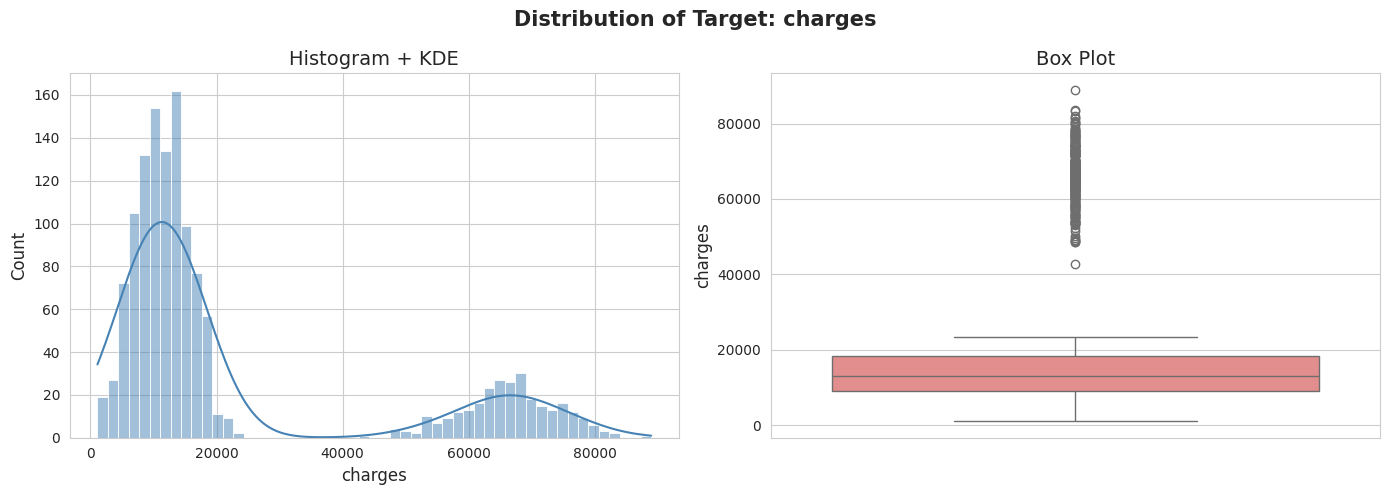

In [8]:
# ── Helper: save and show chart ──────────────────────────────────────
def save_chart(filename: str):
    """Saves the current matplotlib figure to the charts output folder."""
    path = os.path.join(charts_output_folder, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved → {path}")
    plt.show()
    plt.close()


# ── Chart 1: Target Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Distribution of Target: {target_column}", fontsize=15, fontweight='bold')

# Histogram with KDE
sns.histplot(df[target_column], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Histogram + KDE")
axes[0].set_xlabel(target_column)

# Box plot
sns.boxplot(y=df[target_column], ax=axes[1], color='lightcoral')
axes[1].set_title("Box Plot")

plt.tight_layout()
save_chart("01_target_distribution.png")


✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\02_feature_distributions.png


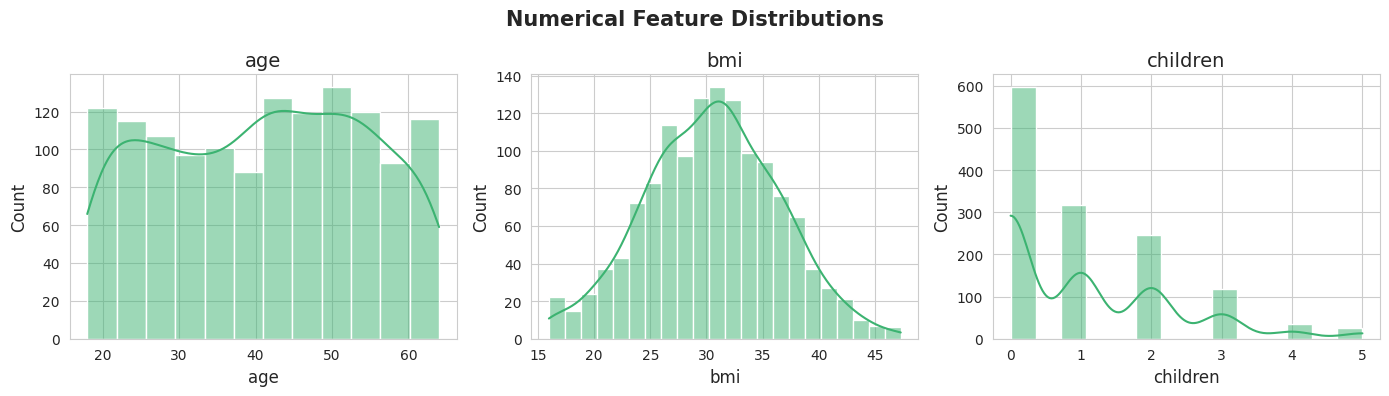

In [9]:
# ── Chart 2: Numerical Feature Distributions ─────────────────────────
num_features = [c for c in num_cols if c != target_column]
n = len(num_features)

if n > 0:
    cols_per_row = 3
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, 4 * rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_features):
        sns.histplot(df[col], kde=True, ax=axes[i], color='mediumseagreen')
        axes[i].set_title(f"{col}")
        axes[i].set_xlabel(col)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Numerical Feature Distributions", fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_chart("02_feature_distributions.png")
else:
    print("No numerical features to plot.")


✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\03_scatter_vs_target.png


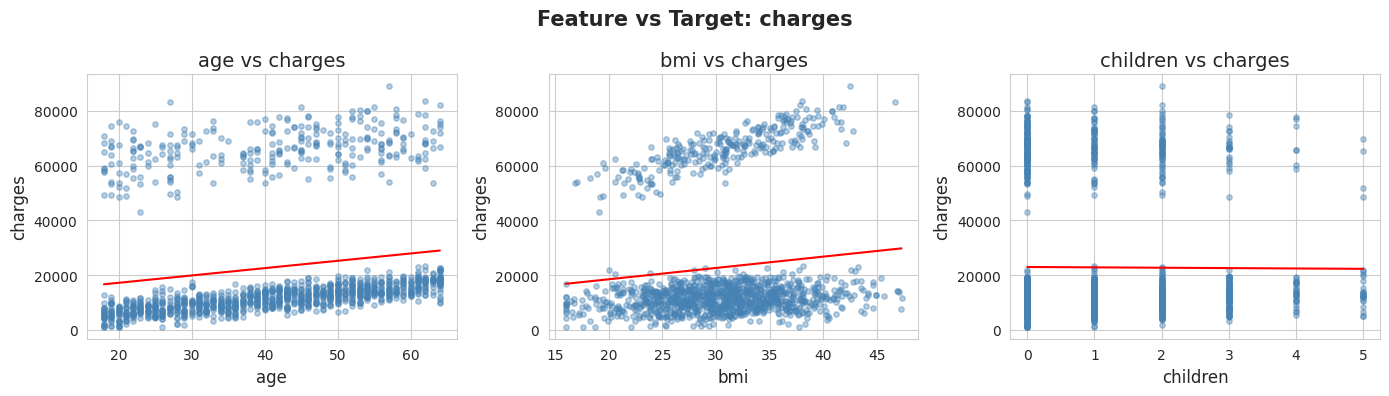

In [10]:
# ── Chart 3: Scatter — Each Numerical Feature vs Target ──────────────
if n > 0:
    cols_per_row = 3
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, 4 * rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_features):
        axes[i].scatter(df[col], df[target_column], alpha=0.4, s=15, color='steelblue')
        # Trend line
        m, b = np.polyfit(df[col], df[target_column], 1)
        axes[i].plot(sorted(df[col]), [m * x + b for x in sorted(df[col])],
                     color='red', linewidth=1.5, label='trend')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_column)
        axes[i].set_title(f"{col} vs {target_column}")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Feature vs Target: {target_column}", fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_chart("03_scatter_vs_target.png")


✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\04_categorical_vs_target.png


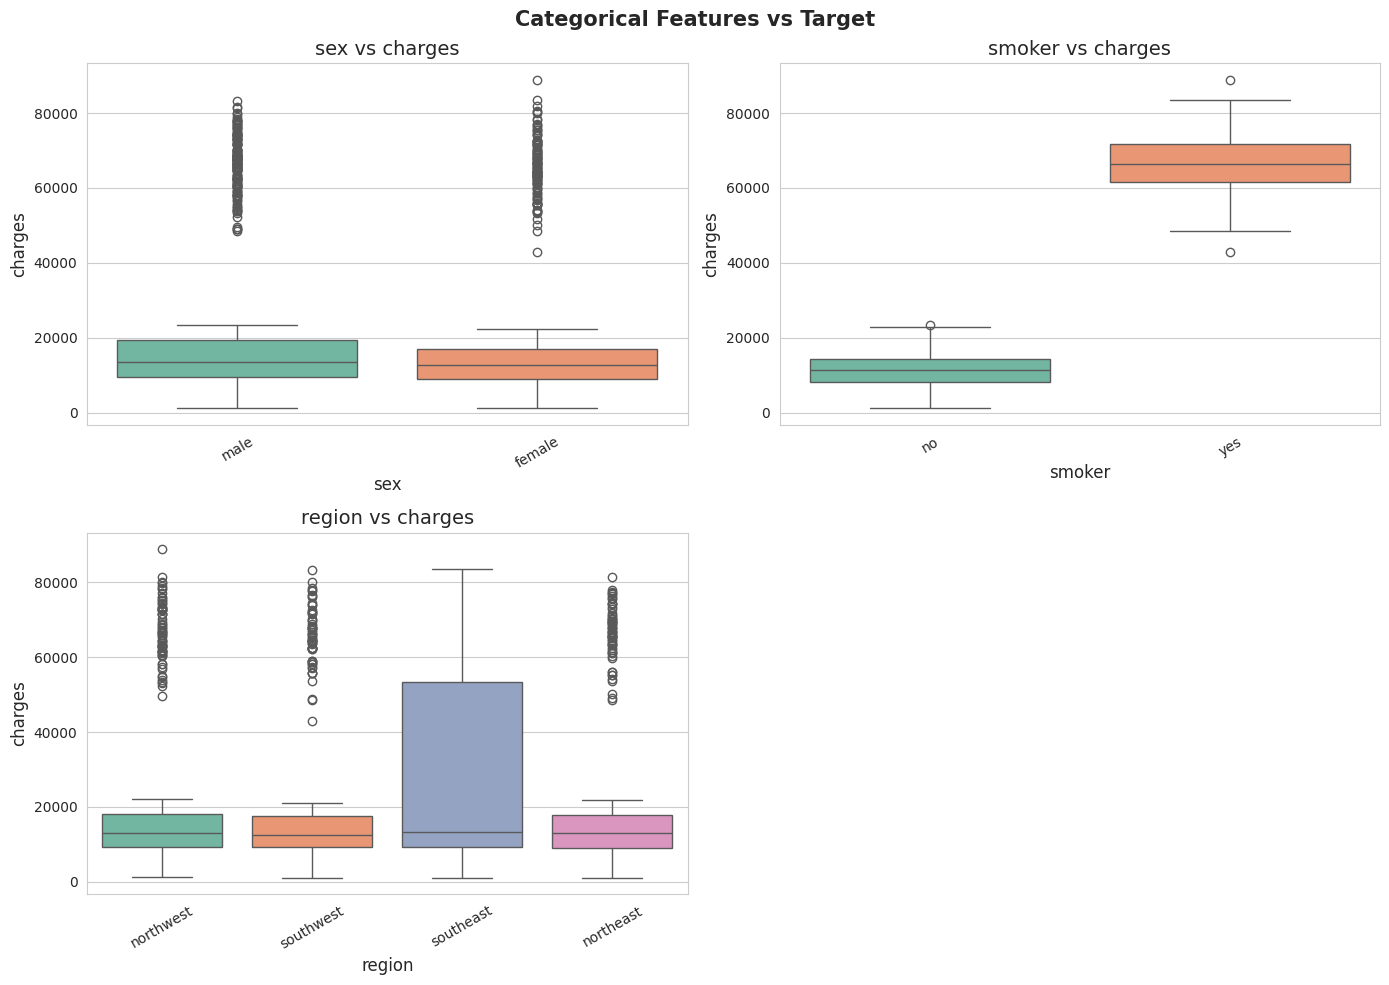

In [11]:
# ── Chart 4: Categorical Columns vs Target ───────────────────────────
if cat_cols:
    n_cat = len(cat_cols)
    cols_per_row = 2
    rows = (n_cat + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, 5 * rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_cols):
        sns.boxplot(x=df[col], y=df[target_column], ax=axes[i], palette='Set2')
        axes[i].set_title(f"{col} vs {target_column}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_column)
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Categorical Features vs Target", fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_chart("04_categorical_vs_target.png")
else:
    print("No categorical columns found — skipping chart 4.")


✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\05_correlation_heatmap.png


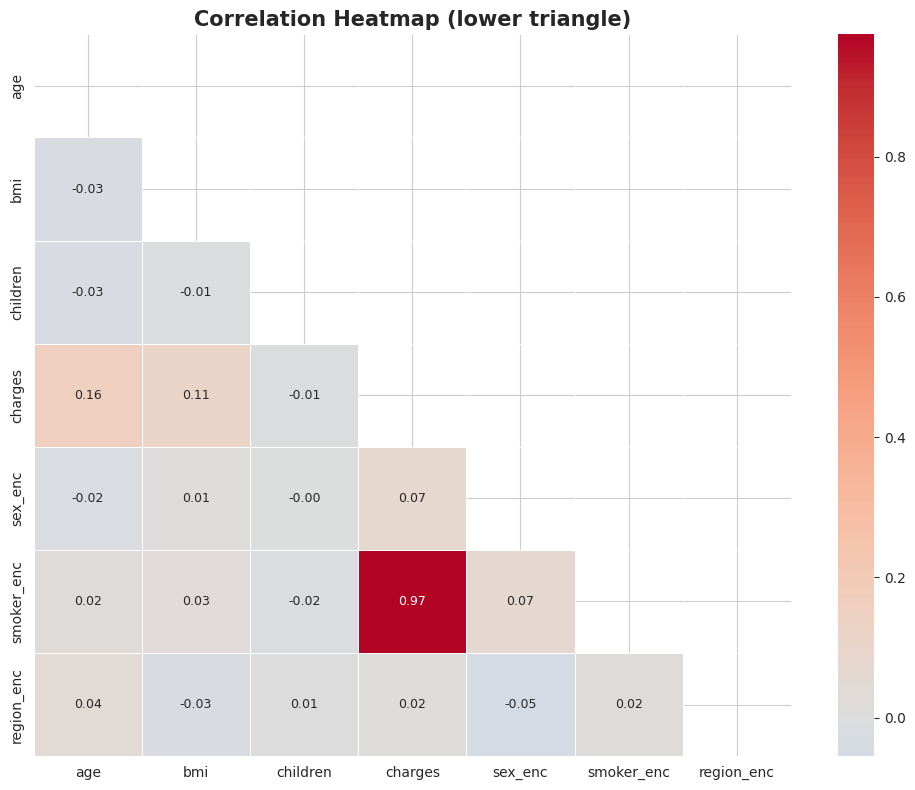


Top correlations with 'charges':
charges       1.000000
smoker_enc    0.974556
age           0.158344
bmi           0.107658
sex_enc       0.073207
region_enc    0.015586
children     -0.007315


In [12]:
# ── Chart 5: Correlation Heatmap ─────────────────────────────────────
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(max(10, len(numeric_df.columns)), max(8, len(numeric_df.columns) - 2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title("Correlation Heatmap (lower triangle)", fontsize=15, fontweight='bold')
plt.tight_layout()
save_chart("05_correlation_heatmap.png")

# Top correlations with target
print(f"\nTop correlations with '{target_column}':")
print(corr_matrix[target_column].sort_values(key=abs, ascending=False).to_string())


✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\06_pairplot.png


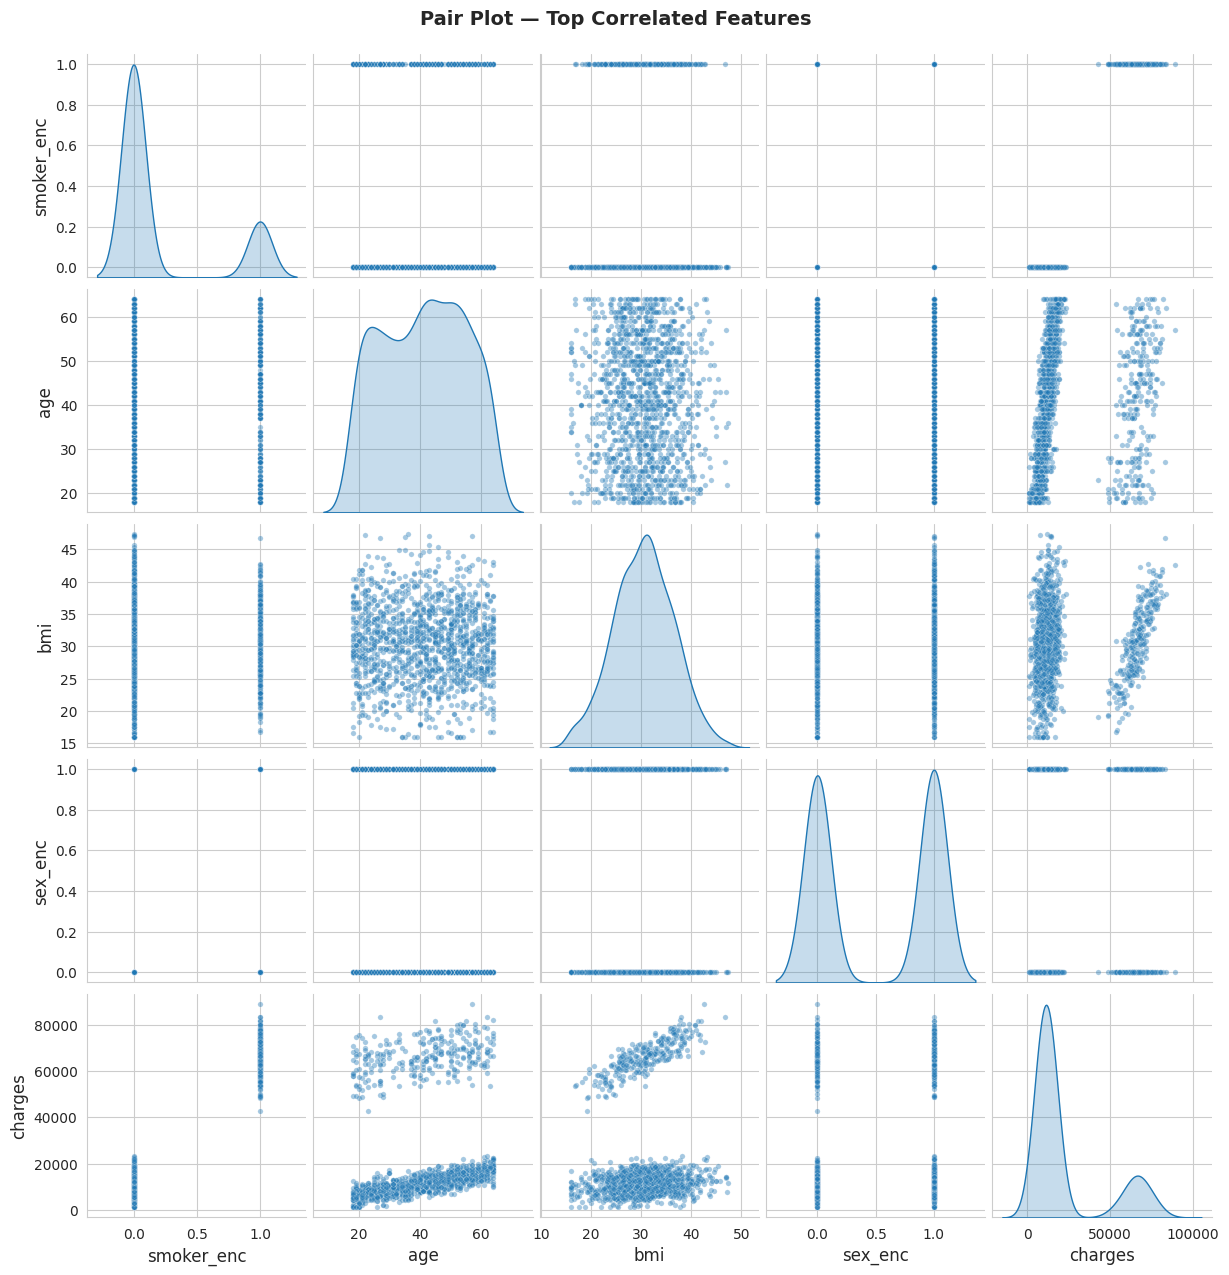

In [13]:
# ── Chart 6: Pair Plot (top correlated features + target) ────────────
# Limit to 5 most correlated features to keep it readable
top_corr_cols = (
    corr_matrix[target_column]
    .drop(target_column)
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)
pair_cols = top_corr_cols + [target_column]

pair_fig = sns.pairplot(df[pair_cols], diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
pair_fig.fig.suptitle("Pair Plot — Top Correlated Features", y=1.02, fontsize=14, fontweight='bold')
pair_path = os.path.join(charts_output_folder, "06_pairplot.png")
pair_fig.savefig(pair_path, dpi=120, bbox_inches='tight')
print(f"✓ Saved → {pair_path}")
plt.show()
plt.close()


## 7. 🔧 Feature Engineering <a id="7-features"></a>

Building the final feature matrix for the model.
- Uses all numeric columns (excluding the raw target)
- Adds encoded categorical columns (suffix `_enc`)
- Target: column selected in Configuration


In [14]:
# ── Build Feature Matrix ─────────────────────────────────────────────
# Keep only numeric columns (includes _enc columns from encoding)
all_numeric = df.select_dtypes(include='number').columns.tolist()

# Exclude the raw target column from features
feature_cols = [c for c in all_numeric if c != target_column]

X = df[feature_cols]
y = df[target_column]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"Target column             : {target_column}")
print(f"X shape                   : {X.shape}")
print(f"y range                   : {y.min():.2f} — {y.max():.2f}")
print(f"y mean                    : {y.mean():.2f}")
X.head(3)


Feature columns (6): ['age', 'bmi', 'children', 'sex_enc', 'smoker_enc', 'region_enc']
Target column             : charges
X shape                   : (1338, 6)
y range                   : 1121.87 — 88913.98
y mean                    : 22792.81


,age,bmi,children,sex_enc,smoker_enc,region_enc
0,56,27.08,2,1,0,1
1,46,29.46,1,0,0,3
2,32,26.03,5,1,0,1


## 8. 🤖 Model Training <a id="8-model"></a>

In [15]:
# ── Train / Test Split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)

print(f"Training set : {X_train.shape[0]:,} rows  ({100*(1-test_size):.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows  ({100*test_size:.0f}%)")


Training set : 1,070 rows  (80%)
Test set     : 268 rows  (20%)


In [16]:
# ── Train Linear Regression ──────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("✓ Model trained successfully")
print(f"  Intercept : {model.intercept_:,.4f}")

# ── Sample predictions ───────────────────────────────────────────────
sample = pd.DataFrame({
    'Actual'   : y_test.values[:8],
    'Predicted': y_pred_test[:8].round(2),
    'Error'    : (y_test.values[:8] - y_pred_test[:8]).round(2)
})
print("\nSample Predictions (first 8 test rows):")
display(sample)


✓ Model trained successfully
  Intercept : -9,011.0855

Sample Predictions (first 8 test rows):


,Actual,Predicted,Error
0,12838.70,11367.44,1471.26
1,11855.52,12552.37,-696.85
2,71910.26,70863.53,1046.73
3,49052.37,58395.90,-9343.53
4,67681.45,69216.10,-1534.65
5,17717.73,18376.18,-658.45
6,62513.22,62898.81,-385.59
7,11516.38,10795.48,720.90


In [17]:
# ── Cross-Validation ─────────────────────────────────────────────────
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("5-Fold Cross-Validation R² Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"\nMean CV R²  : {cv_scores.mean():.4f}")
print(f"Std  CV R²  : {cv_scores.std():.4f}")


5-Fold Cross-Validation R² Scores:
  Fold 1 : 0.9821
  Fold 2 : 0.9763
  Fold 3 : 0.9718
  Fold 4 : 0.9772
  Fold 5 : 0.9773

Mean CV R²  : 0.9769
Std  CV R²  : 0.0033


## 9. 📈 Evaluation & Metrics <a id="9-metrics"></a>

In [18]:
# ── Metric Helper ────────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, label=''):
    """Print and return MAE, RMSE, R² for a set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'='*45}")
    print(f"  {label} Set Metrics")
    print(f"{'='*45}")
    print(f"  MAE  (Mean Absolute Error)   : {mae:>12,.4f}")
    print(f"  RMSE (Root Mean Sq. Error)   : {rmse:>12,.4f}")
    print(f"  R²   (Coefficient of Det.)   : {r2:>12.4f}")
    return mae, rmse, r2


mae_tr, rmse_tr, r2_tr = evaluate_model(y_train, y_pred_train, 'TRAIN')
print()
mae_te, rmse_te, r2_te = evaluate_model(y_test,  y_pred_test,  'TEST')


  TRAIN Set Metrics
  MAE  (Mean Absolute Error)   :   2,647.5715
  RMSE (Root Mean Sq. Error)   :   3,432.1941
  R²   (Coefficient of Det.)   :       0.9777

  TEST Set Metrics
  MAE  (Mean Absolute Error)   :   2,534.4836
  RMSE (Root Mean Sq. Error)   :   3,384.5480
  R²   (Coefficient of Det.)   :       0.9772


✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\07_metrics_dashboard.png


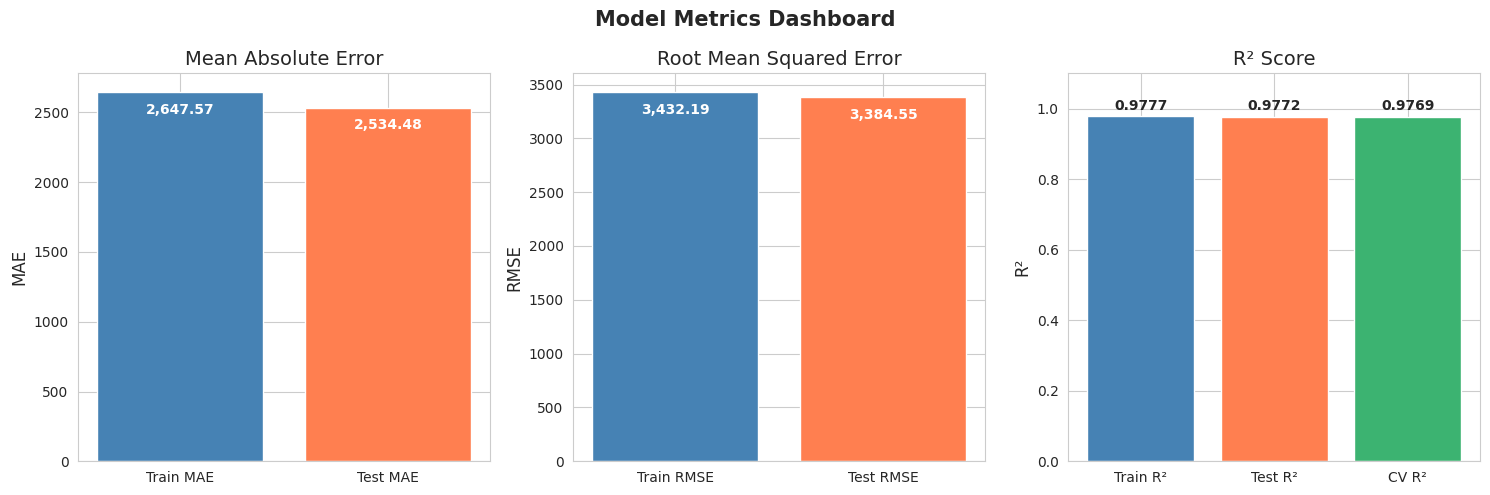

In [19]:
# ── Chart 7: Metrics Dashboard ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Metrics Dashboard", fontsize=15, fontweight='bold')

# Bar: MAE comparison
axes[0].bar(['Train MAE', 'Test MAE'], [mae_tr, mae_te], color=['steelblue', 'coral'])
axes[0].set_title("Mean Absolute Error")
axes[0].set_ylabel("MAE")
for bar, val in zip(axes[0].patches, [mae_tr, mae_te]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.97,
                 f"{val:,.2f}", ha='center', va='top', fontsize=10, color='white', fontweight='bold')

# Bar: RMSE comparison
axes[1].bar(['Train RMSE', 'Test RMSE'], [rmse_tr, rmse_te], color=['steelblue', 'coral'])
axes[1].set_title("Root Mean Squared Error")
axes[1].set_ylabel("RMSE")
for bar, val in zip(axes[1].patches, [rmse_tr, rmse_te]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.97,
                 f"{val:,.2f}", ha='center', va='top', fontsize=10, color='white', fontweight='bold')

# Bar: R² comparison
axes[2].bar(['Train R²', 'Test R²', 'CV R²'],
            [r2_tr, r2_te, cv_scores.mean()],
            color=['steelblue', 'coral', 'mediumseagreen'])
axes[2].set_title("R² Score")
axes[2].set_ylabel("R²")
axes[2].set_ylim([0, 1.1])
for bar, val in zip(axes[2].patches, [r2_tr, r2_te, cv_scores.mean()]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
save_chart("07_metrics_dashboard.png")


Feature Coefficients (sorted by magnitude):
   Feature  Coefficient
smoker_enc 54762.424301
   sex_enc   458.796239
       bmi   337.506406
  children   334.556294
       age   238.568602
region_enc  -179.934705

Intercept: -9,011.0855
✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\08_feature_coefficients.png


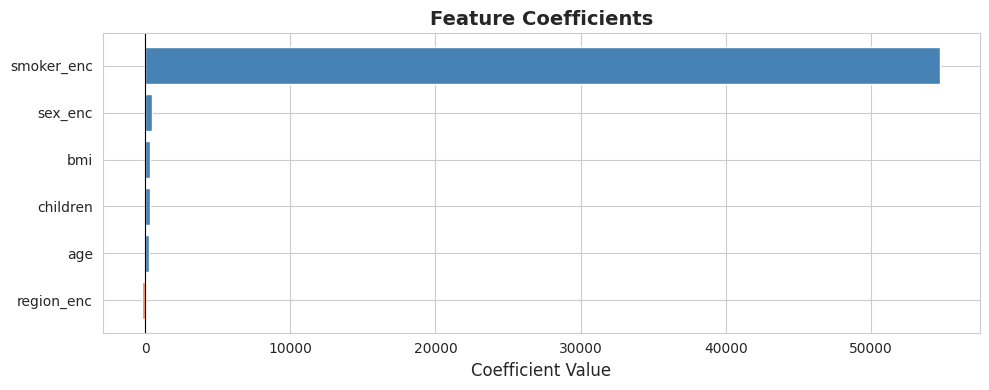

In [20]:
# ── Chart 8: Feature Coefficients ───────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by magnitude):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:,.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, len(feature_cols) * 0.45)))
colors = ['steelblue' if v >= 0 else 'coral' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Coefficients", fontsize=14, fontweight='bold')
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
save_chart("08_feature_coefficients.png")


## 10. 🔬 Residual Analysis <a id="10-residuals"></a>

✓ Saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts\09_residual_analysis.png


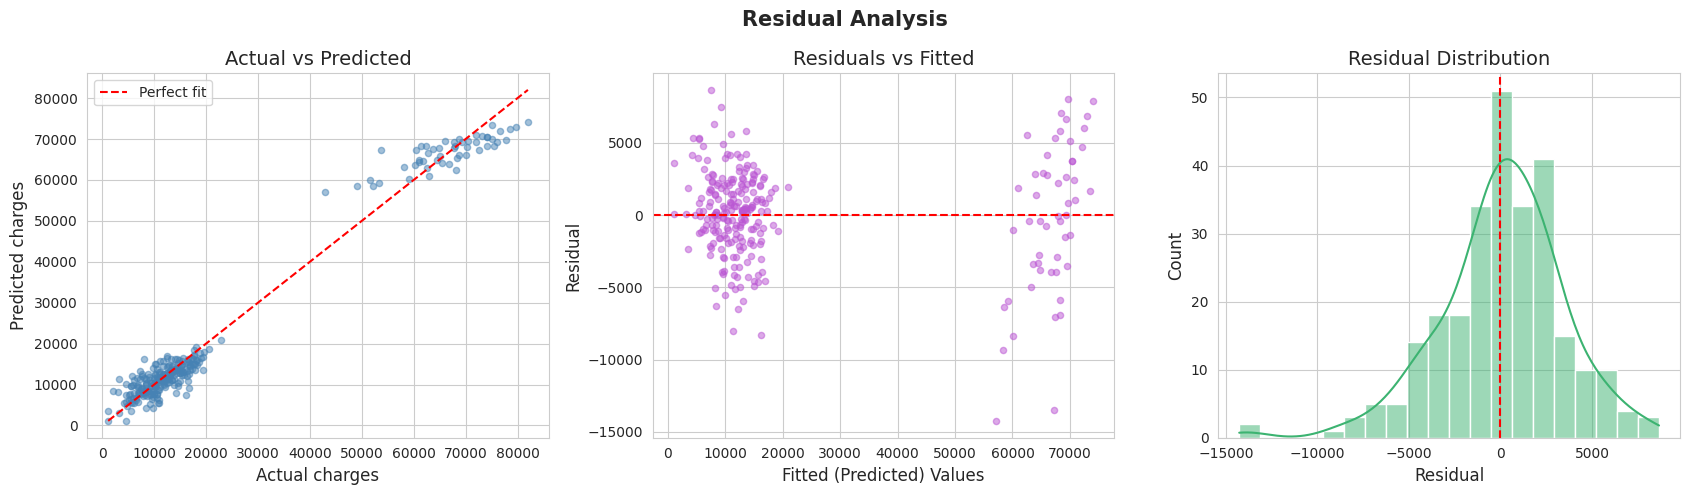

Residual mean : 83.5736  (ideally ≈ 0)
Residual std  : 3383.5161


In [21]:
# ── Chart 9: Residual Analysis ───────────────────────────────────────
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Residual Analysis", fontsize=15, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel(f"Actual {target_column}")
axes[0].set_ylabel(f"Predicted {target_column}")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# Residuals vs Fitted
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=20, color='mediumorchid')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Fitted (Predicted) Values")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted")

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[2], color='mediumseagreen')
axes[2].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_xlabel("Residual")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
save_chart("09_residual_analysis.png")

print(f"Residual mean : {residuals.mean():.4f}  (ideally ≈ 0)")
print(f"Residual std  : {residuals.std():.4f}")


## 11. 💾 Save Model & Summary <a id="11-save"></a>

In [22]:
# ── Save trained model ───────────────────────────────────────────────
model_path = os.path.join(models_output_folder, 'linear_regression.pkl')
joblib.dump(model, model_path)
print(f"✓ Model saved → {model_path}")

# ── Reload and verify ────────────────────────────────────────────────
loaded_model   = joblib.load(model_path)
reload_preds   = loaded_model.predict(X_test[:3])
print(f"✓ Reload test predictions: {reload_preds.round(2)}")


✓ Model saved → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\modelsLDER_PATH_HERE\linear_regression.pkl
✓ Reload test predictions: [11367.44 12552.37 70863.53]


In [23]:
# ── Final Summary ────────────────────────────────────────────────────
print("=" * 55)
print("  PROJECT SUMMARY")
print("=" * 55)
print(f"  Dataset     : {os.path.basename(csv_file_path)}")
print(f"  Rows        : {df_raw.shape[0]:,}    Columns: {df_raw.shape[1]}")
print(f"  Target      : {target_column}")
print(f"  Features    : {len(feature_cols)}")
print(f"  Train/Test  : {100*(1-test_size):.0f}% / {100*test_size:.0f}%")
print("-" * 55)
print("  MODEL PERFORMANCE")
print("-" * 55)
print(f"  Train R²    : {r2_tr:.4f}")
print(f"  Test  R²    : {r2_te:.4f}")
print(f"  CV    R²    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Test  MAE   : {mae_te:,.4f}")
print(f"  Test  RMSE  : {rmse_te:,.4f}")
print("-" * 55)

charts_saved = [f for f in os.listdir(charts_output_folder) if f.endswith('.png')]
print(f"  Charts saved: {len(charts_saved)} PNG files → {charts_output_folder}")
for c in sorted(charts_saved):
    print(f"    {c}")
print("=" * 55)


  PROJECT SUMMARY
  Dataset     : medical_cost.csv
  Rows        : 1,338    Columns: 7
  Target      : charges
  Features    : 6
  Train/Test  : 80% / 20%
-------------------------------------------------------
  MODEL PERFORMANCE
-------------------------------------------------------
  Train R²    : 0.9777
  Test  R²    : 0.9772
  CV    R²    : 0.9769 ± 0.0033
  Test  MAE   : 2,534.4836
  Test  RMSE  : 3,384.5480
-------------------------------------------------------
  Charts saved: 9 PNG files → C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_4\charts
    01_target_distribution.png
    02_feature_distributions.png
    03_scatter_vs_target.png
    04_categorical_vs_target.png
    05_correlation_heatmap.png
    06_pairplot.png
    07_metrics_dashboard.png
    08_feature_coefficients.png
    09_residual_analysis.png
